# D1-07 Contribution analysis and result visualization

This notebook builds on the foreground import from `D1-06` and asks a practical question: which activities and emissions actually drive the result?

We combine standard contribution analysis with a simple foreground-versus-background split, and we finish with an optional Sankey-like view.


## Learning goals

- Extract top process contributions from an LCA result.
- Extract top elementary-flow contributions.
- Compare foreground and background shares of the characterized result.
- Interpret hotspots before moving into regionalised LCIA on Day 2.


## Background references

- Mutel, C. (2017). *Brightway: An open source framework for life cycle assessment*. Journal of Open Source Software, 2(12), 236. https://doi.org/10.21105/joss.00236
- Benitez, A., Wulf, C., de Palmenaer, A., Lengersdorf, M., Röding, T., Grube, T., et al. (2021). Ecological assessment of fuel cell electric vehicles with special focus on type IV carbon fiber hydrogen tank. *Journal of Cleaner Production, 278*, 123277. https://doi.org/10.1016/j.jclepro.2020.123277


## 1) Load the imported foreground database and build one LCA

We use the foreground database written in `D1-06`.
If it is not available yet, run that notebook first.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
import bw2analyzer as ba
import bw2calc as bc
import bw2data as bd

pd.options.display.float_format = '{:,.4f}'.format

bd.projects.set_current('paris-lca-course-2026')
foreground_name = 'carbon fiber'


fg_db = bd.Database(foreground_name)
activity_hits = fg_db.search('carbon fiber', limit=5)
activity = [
    act for act in fg_db if act["name"] == "carbon fiber production, weaved, at factory"
][0]
climate_methods = [m for m in bd.methods if 'climate change' in ' | '.join(m).lower()]
method = climate_methods[0] if climate_methods else next(iter(bd.methods))

lca = bc.LCA({activity: 1}, method)
lca.lci()
lca.lcia()

print('Selected activity:', activity['name'])
print('Method:', method)
print('LCA score:', lca.score)


/opt/homebrew/Caskroom/miniforge/base/envs/lca-course/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


Selected activity: carbon fiber production, weaved, at factory
Method: ('CML v4.8 2016 no LT', 'climate change no LT', 'global warming potential (GWP100) no LT')
LCA score: 54.87816693197386


## 2) Top contributing processes

The `bw2analyzer` contribution utilities annotate the main contributors with readable names.


In [2]:

top_processes = pd.DataFrame(
    [
        {'score': score, 'supply': amount, 'name': node['name']}
        for score, amount, node in ba.ContributionAnalysis().annotated_top_processes(lca=lca)
    ]
)
display(top_processes.head(10))


,score,supply,name
0,9.5376,169.7743,"Natural gas, burned in industrial furnace 1MWth"
1,7.4486,10.6100,"carbon fiber production, exhaust gas treatment 2"
2,4.5148,3.0891,"Propylene, at plant"
3,3.0378,39.3098,"Heavy fuel oil, burned in industrial furnace 1..."
4,2.2949,40.8676,"Natural gas, burned in power plant or heat plant"
5,1.5618,0.0953,"Natural gas, vented"
6,1.5383,1.0505,"Ammonia, steam reforming, liquid, at plant"
7,1.5329,3.1411,"Acrylonitrile from Sohio process, at plant"
8,1.3228,13.0167,"Lignite, burned in power plant"
9,1.2875,12.6630,"Lignite, burned in power plant"


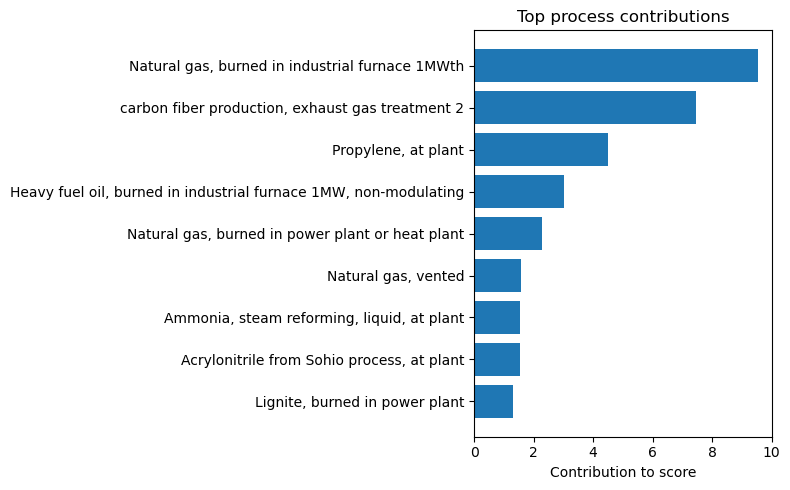

In [3]:
plot_df = top_processes.head(10).iloc[::-1]
plt.figure(figsize=(8, 5))
plt.barh(plot_df['name'], plot_df['score'])
plt.xlabel('Contribution to score')
plt.title('Top process contributions')
plt.tight_layout()
plt.show()


## 3) Top contributing elementary flows

This tells us which emissions or resource uses dominate the result.


In [4]:

top_emissions = pd.DataFrame(
    [
        {'score': score, 'amount': amount, 'name': node['name']}
        for score, amount, node in ba.ContributionAnalysis().annotated_top_emissions(lca=lca)
    ]
)
display(top_emissions.head(10))


,score,amount,name
0,31.5260,31.5260,"Carbon dioxide, fossil"
1,11.2426,11.2426,"Carbon dioxide, fossil"
2,7.1631,7.1631,"Carbon dioxide, fossil"
3,1.6073,0.0574,"Methane, fossil"
4,1.5917,0.0568,"Methane, fossil"
5,1.0499,0.0375,"Methane, fossil"
6,0.1896,0.0068,"Methane, non-fossil"
7,0.1762,0.0000,Sulfur hexafluoride
8,0.0876,0.0003,Dinitrogen monoxide
9,0.0821,0.0029,"Methane, non-fossil"


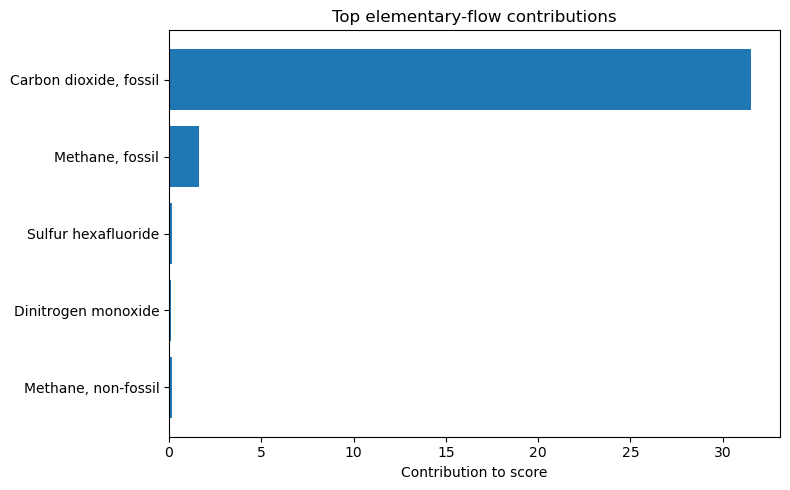

In [5]:
plot_df = top_emissions.head(10).iloc[::-1]
plt.figure(figsize=(8, 5))
plt.barh(plot_df['name'], plot_df['score'])
plt.xlabel('Contribution to score')
plt.title('Top elementary-flow contributions')
plt.tight_layout()
plt.show()


## 4) Foreground versus background share

A useful transition question for Day 2 is whether the result is driven mostly by the imported foreground system or by background supply chains.


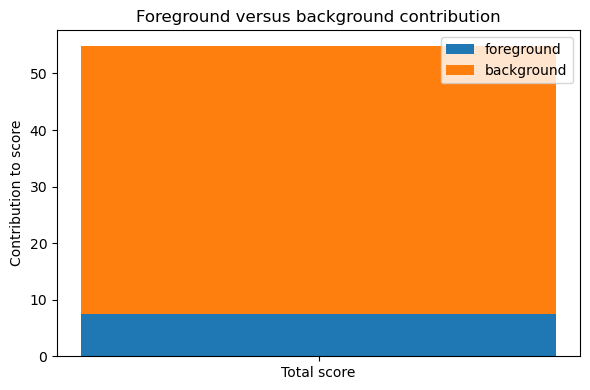

In [6]:
char_inv = lca.characterized_inventory.tocsr()
activity_contrib = np.asarray(char_inv.sum(axis=0)).ravel()
reverse_activity = lca.dicts.activity.reversed

foreground_score = 0.0
background_score = 0.0
for idx, value in enumerate(activity_contrib):
    node = bd.get_node(id=reverse_activity[idx])
    if node.key[0] == foreground_name:
        foreground_score += value
    else:
        background_score += value

share_df = pd.DataFrame({
    'segment': ['foreground', 'background'],
    'score': [foreground_score, background_score],
})

plt.figure(figsize=(6, 4))
plt.bar(['Total score'], [share_df['score'].sum()], color='lightgrey')
plt.bar(['Total score'], [share_df.loc[0, 'score']], label='foreground')
plt.bar(['Total score'], [share_df.loc[1, 'score']], bottom=[share_df.loc[0, 'score']], label='background')
plt.ylabel('Contribution to score')
plt.title('Foreground versus background contribution')
plt.legend()
plt.tight_layout()
plt.show()


## 5) Optional Sankey-like view with `polyviz`

If [`polyviz`](https://github.com/Laboratory-for-Energy-Systems-Analysis/polyviz) is available in the environment, we can try a more structural visualization.
This is optional and may be skipped during live teaching if time is short.


In [7]:
from polyviz import sankey

_, sankey_df = sankey(activity=activity, level=7, cutoff=0.01, method=method)

Calculating supply chain score...
Sankey diagram generated.


`polyviz` has other types of visualization, depending on what it is you'd like to show.

In [8]:
from polyviz import chord, choro, force, treemap, violin

In [9]:
treemap(activity=activity, cutoff=0.01, method=method)

Calculating LCIA score...


'/Users/romain/GitHub/paris-mines-lca-school-2026/tutorials/DAY 1 - Brightway Foundations/carbon fiber production weaved at factory kilogram RER CML v48 2016 no LTclimate change no LTglobal warming potential GWP100 no LT treemap.html'

## Checkpoint

Based on the process table, emission table, and foreground/background split, answer three questions:

1. Which process is the main hotspot?
2. Which elementary flow is the main hotspot?
3. Is the score mostly foreground-driven or background-driven?


In [ ]:
# TODO
# Write a short interpretation here.


In [ ]:
if 'top_processes' in globals() and 'top_emissions' in globals() and 'share_df' in globals():
    print('Largest process contributor:', top_processes.iloc[0]['name'])
    print('Largest elementary-flow contributor:', top_emissions.iloc[0]['name'])
    dominant_segment = share_df.sort_values('score', ascending=False).iloc[0]['segment']
    print('Dominant segment:', dominant_segment)
    print('This is the bridge to Day 2: once we know the hotspots, we can ask whether their impacts change by region.')


## Recap

After this notebook, you should now be able to:

- extract top process and top emission contributors
- visualize key hotspots
- separate foreground and background contributions
- explain why hotspot structure matters before regionalising impacts
